## Arquitectura del Clasificador

### Contexto y rol en la tarea

Este clasificador es un juez automático, independiente de las redes de difusión. Se entrena sobre datos reales limpios $x_0 \sim p_{\text{data}}$, sin ruido, sin dependencia de $t$ y sin condicionar en $y$. Su único rol es medir la fidelidad ($\arg\max_y P(y\mid x)$) y aportar los logits para las métricas de diversidad sobre las muestras sintéticas.

### Diseño general

La arquitectura sigue una jerarquía de bloques convolucionales que proyecta la imagen desde el espacio de píxeles a un espacio de características $\Phi(x)$ de menor dimensión, seguida de un bloque totalmente conectado (FC) que actúa como estimador de $P(y\mid x)$ y ejecuta la decisión final.

### Selección de hiperparámetros

La mayoría de las decisiones de este modelo son prácticas estándar en visión por computador, no ajustes específicos a este problema:

- **Kernels $3\times3$, stride 1, padding 1**: convención popularizada por VGG — apilar convoluciones pequeñas logra campos receptivos grandes con menos parámetros que un kernel único más grande.
- **Duplicar canales al reducir resolución (1→16→32)**: patrón estándar en arquitecturas convolucionales (VGG, ResNet) — al perder resolución espacial se compensa con más canales, manteniendo la capacidad de representación.
- **BatchNorm después de cada conv**: introducido por Ioffe & Szegedy (2015), estándar en casi cualquier CNN moderna para estabilizar y acelerar el entrenamiento.
- **Dropout $p=0.2$ en la cabeza FC**: técnica de Srivastava et al. (2014), aplicada convencionalmente solo en capas densas, donde se concentra la mayoría de los parámetros del modelo.
- **Dos bloques conv+pool**: suficiente para MNIST, donde los dígitos son simples y de bajo detalle; arquitecturas más profundas (ResNet, etc.) están pensadas para datasets con mayor complejidad visual (ImageNet).

En conjunto, la arquitectura es una CNN pequeña en la tradición de LeNet-5, con los ajustes modernos de BatchNorm y Dropout que se volvieron estándar después.

### Justificación del orden de las capas (`Conv → BatchNorm → ReLU → MaxPool`)

El orden no es arbitrario, y cada paso depende del anterior:

1. **`Conv → BatchNorm`**: la convolución altera drásticamente la escala de los valores. Normalizar inmediatamente después estabiliza esos números antes de que lleguen a cualquier otra capa.
2. **`BatchNorm → ReLU`**: si la ReLU fuera antes, truncaría todos los valores negativos a cero, destruyendo la distribución real de los datos — BatchNorm necesita ver la distribución completa (positiva y negativa) para calcular una media y varianza representativas.
3. **`ReLU → MaxPool`**: se activa antes de resumir por eficiencia. Aplicar ReLU primero define qué rasgos existen; MaxPool después resume su posición espacial. Invertir el orden no cambiaría el resultado final (ambas son monótonas), pero sí el costo: MaxPool antes de ReLU forzaría a la red a arrastrar valores negativos que de todas formas van a ser eliminados.
4. **`Dropout` solo al final, en el bloque FC**: aplicarlo en los bloques convolucionales rompería la continuidad geométrica de la imagen (bordes y líneas vecinas), dañando la capacidad de los filtros para detectar rasgos continuos. En la cabeza densa no hay esa restricción espacial, por lo que apagar neuronas al azar solo rompe co-adaptaciones entre features, que es el efecto deseado.

### Salida: 10 clases, sin softmax

`forward()` retorna logits crudos, sin capa `Softmax` explícita, porque `nn.CrossEntropyLoss` la aplica internamente de forma numéricamente estable. No hay token nulo — a diferencia de la red de difusión con CFG, este es un problema de clasificación cerrado (dígitos 0-9), sin necesidad de una clase "vacía".

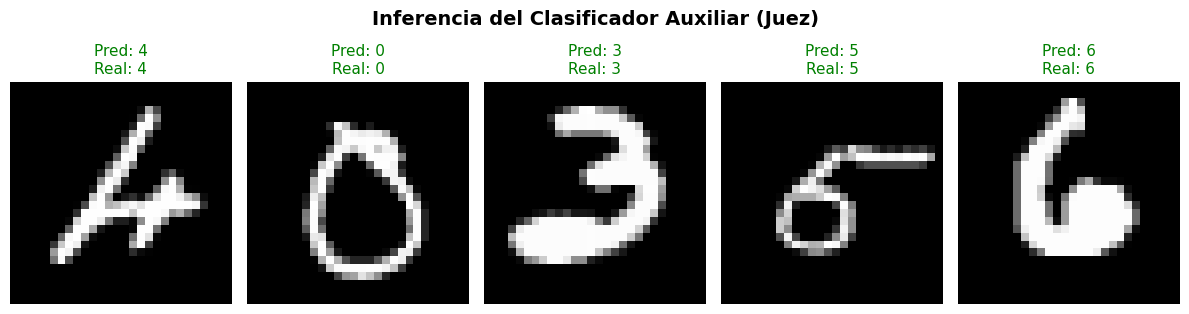

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from pathlib import Path

from src.model_clf import Clasificador  # Si el notebook está en la raíz

# 2. Configurar hardware y cargar el Checkpoint guardado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = Path("outputs/clasificador.pt")

ckpt = torch.load(checkpoint_path, map_location=device)
model = Clasificador(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

# 3. Cargar el set de Validación/Test original para evaluar
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# 4. Tomar 5 muestras aleatorias y clasificarlas en batch
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
indices = torch.randint(0, len(test_dataset), (5,))

for i, idx in enumerate(indices):
    img_tensor, true_label = test_dataset[idx]

    # Preparar imagen para el modelo: agregar dimensión de batch (1, 1, 28, 28)
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred_label = logits.argmax(dim=1).item()

    # Desnormalizar la imagen para mostrarla correctamente (volver a rango 0-1)
    img_show = img_tensor.squeeze().numpy() * 0.5 + 0.5

    # Graficar
    axes[i].imshow(img_show, cmap="gray")
    color = "green" if pred_label == true_label else "red"
    axes[i].set_title(
        f"Pred: {pred_label}\nReal: {true_label}", color=color, fontsize=11
    )
    axes[i].axis("off")

plt.suptitle(
    "Inferencia del Clasificador Auxiliar (Juez)", fontsize=14, weight="bold", y=1.05
)
plt.tight_layout()
plt.show()

## Función de costo: Cross-Entropy

El objetivo es maximizar la verosimilitud de las etiquetas reales bajo el modelo, lo que equivale a minimizar el negativo del log de la probabilidad predicha:

$$-\mathbb{E}_{(x,y)\sim p_{\text{data}}}\big[\log p_\theta(y \mid x)\big] = \mathbb{E}_{(x,y)\sim p_{\text{data}}}\Big[-\log\big(\text{Softmax}(f_\theta(x))_y\big)\Big]$$

En PyTorch esto se implementa con `nn.CrossEntropyLoss()`, **sin** aplicar una capa `Softmax` explícita antes. Dos razones:

- **Estabilidad numérica.** Calcular `Softmax` y luego `log` por separado es propenso a overflow/underflow cuando los logits son grandes. `CrossEntropyLoss` fusiona ambas operaciones internamente vía el truco *log-sum-exp*, lo que mantiene los gradientes estables y evita `NaN`.
- **Aproximación de la esperanza.** Como $p_{\text{data}}$ es desconocida, $\mathbb{E}$ se estima empíricamente promediando sobre cada mini-batch de tamaño $B$:

$$\mathcal{L}_{\text{batch}} = \frac{1}{B}\sum_{i=1}^{B} -\log\left(\frac{e^{f_\theta(x_i)_{y_i}}}{\sum_j e^{f_\theta(x_i)_j}}\right)$$

## Train loss vs. Val loss

El dataset se divide en dos conjuntos disjuntos: **entrenamiento (90%)** y **validación (10%)**, para medir generalización de forma honesta.

- **Train loss**: costo calculado sobre los datos que el modelo efectivamente ve — Adam usa este error para actualizar los pesos vía `loss.backward()`.
- **Val loss**: costo sobre datos que el modelo nunca usa para optimizar. Se calcula con `model.eval()`, donde la red actúa puramente como inferencia (sin actualizar parámetros).

## Lectura de la curva obtenida

- **Convergencia rápida.** La pérdida de entrenamiento parte alta ($\approx 0.20$ en la época 0) y cae de forma pronunciada ya en la época 1, señal de que el learning rate ($10^{-3}$) junto con Adam encuentran rápido una región estable del espacio de parámetros.
- **Sin overfitting visible.** La curva de validación se mantiene consistentemente igual o por debajo de la de entrenamiento. Si el modelo estuviera memorizando, veríamos la train loss seguir bajando mientras la val loss empieza a subir. Acá ambas decrecen en paralelo, lo que indica buena capacidad de generalización a datos no vistos.